<a href="https://colab.research.google.com/github/afullhart/climateanalogs/blob/main/Figures/Tables.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%reset -f

### Imports

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### ZeroOne Ecoregion Lvl 3 Accuracy

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


fld = '/content/drive/My Drive/Colab Notebooks/Analogs/Binary_Test'

files = [f for f in os.listdir(fld) if f[-4:] == '.csv']
print(files)


test_groups = ['34', '125671012', '101114', '81315', '912']
diag_group = [['14', '81'], ['13', '20', '22', '24'], ['5', '18', '19', '21', '80'], ['23', '79'], ['25', '26']]


df_dict = {}
for n in test_groups:
  df = pd.read_csv(os.path.join(fld, 'Zonal_eco3_{}.csv'.format(n)))
  mask = df.iloc[:, 1:].any(axis=1)
  df = df.iloc[:, 1:][mask]
  n_classes = len(df)
  df_dict[n] = df

display(df)

true_positive_rate_list = []
true_negative_rate_list = []
area_norm_list = []
test_scores = []
avg_area_norm = 0.0
for i, df_key in enumerate(df_dict):
  df = df_dict[df_key]
  n = df.sum().sum()
  sum_values_per_col = df.sum()
  codes = ['US_L3_' + diag_group[i][j] for j in range(len(diag_group[i]))]
  anti_codes = [c for c in df.columns.to_list() if c not in codes]
  yes_n = float(df[codes].loc[255, :].sum())
  no_n = float(df[codes].loc[0, :].sum())
  anti_yes_n = float(df[anti_codes].loc[255, :].sum())
  anti_no_n = float(df[anti_codes].loc[0, :].sum())
  area_n = yes_n + no_n
  anti_area_n = anti_yes_n + anti_no_n

  true_positive = yes_n
  true_negative = anti_no_n
  false_positive = anti_yes_n
  false_negative =  no_n

  group_accuracy = (true_positive + true_negative) / (true_positive + true_negative + false_positive + false_negative)
  print(group_accuracy)
  test_scores.append(group_accuracy)
  true_positive_rate = yes_n / (yes_n + no_n)
  true_negative_rate = anti_no_n / (anti_no_n + anti_yes_n)
  true_positive_rate_list.append(true_positive_rate)
  true_negative_rate_list.append(true_negative_rate)
  area_norm = (true_positive_rate + true_negative_rate) / 2.0
  area_norm_list.append(area_norm)
  avg_area_norm += area_norm * (area_n / n)

print(f'Average accuracy score: {np.average(test_scores)*100}')
print(f'Average true positive rate: {np.average(true_positive_rate_list)*100}')
print(f'Average true negative rate: {np.average(true_negative_rate_list)*100}')
print(f'Area-norm classification rate: {np.average(area_norm_list)*100}')
#print(f'Average area-norm classification rate: {avg_area_norm*100}')


['Zonal_eco3_125671012.csv', 'Zonal_eco3_34.csv', 'Zonal_eco3_81315.csv', 'Zonal_eco3_912.csv', 'Zonal_eco3_101114.csv', 'Zonal_mlra_12567812.csv', 'Zonal_mlra_34.csv', 'Zonal_mlra_813.csv', 'Zonal_mlra_912.csv', 'Zonal_mlra_101114.csv', 'Zonal_mlra_15.csv']


,US_L3_13,US_L3_14,US_L3_18,US_L3_19,US_L3_20,US_L3_21,US_L3_22,US_L3_23,US_L3_24,US_L3_25,US_L3_26,US_L3_5,US_L3_79,US_L3_80,US_L3_81
0,418401,76411,3662,64570,146992,38167,195033,152034,71140,4,11814,1345,53556,60889,124827
255,26645,10,873,1269,1588,1488,3021,3920,29023,45717,89401,53,708,870,7


0.9753135013471411
0.8180269280379048
0.8251285235407819
0.9030606650823746
0.9499254052202795
Average accuracy score: 89.42910046456964
Average true positive rate: 83.86382003889365
Average true negative rate: 91.43628028273247
Area-norm classification rate: 87.65005016081305


### ZeroOne MLRA Accuracy

In [24]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt


fld = '/content/drive/My Drive/Colab Notebooks/Analogs/Binary_Test'

files = [f for f in os.listdir(fld) if f[-4:] == '.csv']
print(files)


test_groups = ['34', '1256712', '101114', '813', '15', '912']
diag_group = [['30', '40'], ['24', '27', '28A', '29', '34A', '34B', '35', '42B'],
                ['11', '13', '22A', '23', '25', '26', '28B', '36', '46', '47', '48A', '51'], ['38', '41'],
                ['39'], ['42A', '42C', '70A', '70B', '77B', '77C', '77D', '77E']]


df_dict = {}
for n in test_groups:
  df = pd.read_csv(os.path.join(fld, 'Zonal_mlra_{}.csv'.format(n)))
  mask = df.iloc[:, 1:].any(axis=1)
  df = df.iloc[:, 1:][mask]
  n_classes = len(df)
  df_dict[n] = df

display(df)

true_positive_rate_list = []
true_negative_rate_list = []
area_norm_list = []
test_scores = []
avg_area_norm = 0.0
for i, df_key in enumerate(df_dict):
  df = df_dict[df_key]
  n = df.sum().sum()
  sum_values_per_col = df.sum()
  codes = ['MLRAR_' + diag_group[i][j] for j in range(len(diag_group[i]))]
  anti_codes = [c for c in df.columns.to_list() if c not in codes]
  yes_n = float(df[codes].loc[255, :].sum())
  no_n = float(df[codes].loc[0, :].sum())
  anti_yes_n = float(df[anti_codes].loc[255, :].sum())
  anti_no_n = float(df[anti_codes].loc[0, :].sum())
  area_n = yes_n + no_n
  anti_area_n = anti_yes_n + anti_no_n

  true_positive = yes_n
  true_negative = anti_no_n
  false_positive = anti_yes_n
  false_negative =  no_n

  group_accuracy = (true_positive + true_negative) / (true_positive + true_negative + false_positive + false_negative)
  print(group_accuracy)
  test_scores.append(group_accuracy)
  true_positive_rate = yes_n / (yes_n + no_n)
  true_negative_rate = anti_no_n / (anti_no_n + anti_yes_n)
  true_positive_rate_list.append(true_positive_rate)
  true_negative_rate_list.append(true_negative_rate)
  area_norm = (true_positive_rate + true_negative_rate) / 2.0
  area_norm_list.append(area_norm)
  avg_area_norm += area_norm * (area_n / n)

print(f'Average accuracy score: {np.average(test_scores)*100}')
print(f'Average true positive rate: {np.average(true_positive_rate_list)*100}')
print(f'Average true negative rate: {np.average(true_negative_rate_list)*100}')
print(f'Area-norm classification rate: {np.average(area_norm_list)*100}')
#print(f'Average area-norm classification rate: {avg_area_norm*100}')



['Zonal_eco3_101114.csv', 'Zonal_mlra_912.csv', 'Zonal_mlra_813.csv', 'Zonal_mlra_34.csv', 'Zonal_mlra_1256712.csv', 'Zonal_mlra_101114.csv', 'Zonal_mlra_15.csv', 'Zonal_eco3_912.csv', 'Zonal_eco3_81315.csv', 'Zonal_eco3_125671012.csv', 'Zonal_eco3_34.csv']


,MLRAR_11,MLRAR_13,MLRAR_22A,MLRAR_23,MLRAR_24,MLRAR_25,MLRAR_26,MLRAR_27,MLRAR_28A,MLRAR_28B,...,MLRAR_46,MLRAR_47,MLRAR_48A,MLRAR_51,MLRAR_70A,MLRAR_70B,MLRAR_77B,MLRAR_77C,MLRAR_77D,MLRAR_77E
0,228,1543,1311,19377,39206,62570,15025,59036,123280,84630,...,2458,73315,40551,1812,1348,649,0,0,0,0
255,37,786,66,147,1186,1618,382,1106,22585,749,...,19,888,1930,25,29930,55782,5817,8661,18505,1083


0.9795316846491022
0.8194724029773887
0.8549527052498528
0.91743745980747
0.9430578107175152
0.9547004008781375
Average accuracy score: 91.15254107132445
Average true positive rate: 73.59654859167262
Average true negative rate: 93.90369558955743
Area-norm classification rate: 83.75012209061502


### Zscore Ecoregion Lvl 3 Accuracy

In [ ]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt

fld = '/content/drive/My Drive/Colab Notebooks/Analogs/Binary_Test'

files = [f for f in os.listdir(fld) if f[-4:] == '.csv']
print(files)

test_groups = ['134', '2567812', '91115', '9121314', '10']
diag_group = [['14', '81'], ['13', '18', '20', '22', '24'], ['23', '79'], ['5', '19', '21', '80'], ['25', '26']]

df_dict = {}
for n in test_groups:
  df = pd.read_csv(os.path.join(fld, 'Zonal_eco3_{}.csv'.format(n)))
  mask = df.iloc[:, 1:].any(axis=1)
  df = df.iloc[:, 1:][mask]
  n_classes = len(df)
  df_dict[n] = df

display(df)

true_positive_rate_list = []
true_negative_rate_list = []
area_norm_list = []
test_scores = []
for i, df_key in enumerate(df_dict):
  df = df_dict[df_key]
  n = df.sum().sum()
  sum_values_per_col = df.sum()
  codes = ['US_L3_' + diag_group[i][j] for j in range(len(diag_group[i]))]
  anti_codes = [c for c in df.columns.to_list() if c not in codes]
  yes_n = float(df[codes].loc[255, :].sum())
  no_n = float(df[codes].loc[0, :].sum())
  anti_yes_n = float(df[anti_codes].loc[255, :].sum())
  anti_no_n = float(df[anti_codes].loc[0, :].sum())
  area_n = yes_n + no_n
  anti_area_n = anti_yes_n + anti_no_n

  true_positive = yes_n
  true_negative = anti_no_n
  false_positive = anti_yes_n
  false_negative =  no_n

  group_accuracy = (true_positive + true_negative) / (true_positive + true_negative + false_positive + false_negative)
  print(group_accuracy)
  test_scores.append(group_accuracy)
  true_positive_rate = yes_n / (yes_n + no_n)
  true_negative_rate = anti_no_n / (anti_no_n + anti_yes_n)
  true_positive_rate_list.append(true_positive_rate)
  true_negative_rate_list.append(true_negative_rate)
  area_norm = (true_positive_rate + true_negative_rate) / 2.0
  area_norm_list.append(area_norm)

print(f'Average accuracy score: {np.average(test_scores)*100}')
print(f'Average true positive rate: {np.average(true_positive_rate_list)*100}')
print(f'Average true negative rate: {np.average(true_negative_rate_list)*100}')
print(f'Area-norm classification rate: {np.average(area_norm_list)*100}')



['Zonal_eco3_125671012.csv', 'Zonal_eco3_34.csv', 'Zonal_eco3_81315.csv', 'Zonal_eco3_912.csv', 'Zonal_eco3_101114.csv', 'Zonal_mlra_125678.csv', 'Zonal_mlra_34.csv', 'Zonal_mlra_813.csv', 'Zonal_mlra_912.csv', 'Zonal_mlra_101114.csv', 'Zonal_mlra_15.csv', 'Zonal_eco3_134.csv', 'Zonal_eco3_2567812.csv', 'Zonal_eco3_91115.csv', 'Zonal_eco3_9121314.csv', 'Zonal_eco3_10.csv', 'Zonal_mlra_13.csv', 'Zonal_mlra_24568.csv', 'Zonal_mlra_7912.csv', 'Zonal_mlra_10.csv', 'Zonal_mlra_11.csv', 'Zonal_mlra_1314.csv']


,US_L3_13,US_L3_14,US_L3_18,US_L3_19,US_L3_20,US_L3_21,US_L3_22,US_L3_23,US_L3_24,US_L3_25,US_L3_26,US_L3_5,US_L3_79,US_L3_80,US_L3_81
0,349970,76336,2270,61174,132988,35981,156995,139485,70987,4,6484,1321,53555,42179,124827
255,95076,85,2265,4665,15592,3674,41059,16469,29176,45717,94731,77,709,19580,7


0.9294183085525902
0.7086165286262857
0.7161733309187046
0.7435818306581464
0.8552935190626313
Average accuracy score: 79.06167035636716
Average true positive rate: 62.01717325119166
Average true negative rate: 83.82380580552118
Area-norm classification rate: 72.92048952835641


### Zscore MLRA Accuracy

In [ ]:

import os
import pandas as pd
import matplotlib.pyplot as plt


fld = '/content/drive/My Drive/Colab Notebooks/Analogs/Binary_Test'

files = [f for f in os.listdir(fld) if f[-4:] == '.csv']
print(files)

test_groups = ['13', '24568', '7912', '10', '11', '1314']
diag_group = [['30', '40'], ['24', '26', '27', '28A', '29', '34B', '35', '42B'],
              ['11', '13', '23', '25', '28B', '34A', '36', '39', '51'], ['42A', '42C', '70A', '70B', '77B', '77C', '77D', '77E'],
              ['38', '41'], ['22A', '46', '47', '48A']]

df_dict = {}
for n in test_groups:
  df = pd.read_csv(os.path.join(fld, 'Zonal_mlra_{}.csv'.format(n)))
  mask = df.iloc[:, 1:].any(axis=1)
  df = df.iloc[:, 1:][mask]
  n_classes = len(df)
  df_dict[n] = df

display(df)

true_positive_rate_list = []
true_negative_rate_list = []
area_norm_list = []
test_scores = []
for i, df_key in enumerate(df_dict):
  df = df_dict[df_key]
  n = df.sum().sum()
  sum_values_per_col = df.sum()
  codes = ['MLRAR_' + diag_group[i][j] for j in range(len(diag_group[i]))]
  anti_codes = [c for c in df.columns.to_list() if c not in codes]
  yes_n = float(df[codes].loc[255, :].sum())
  no_n = float(df[codes].loc[0, :].sum())
  anti_yes_n = float(df[anti_codes].loc[255, :].sum())
  anti_no_n = float(df[anti_codes].loc[0, :].sum())
  area_n = yes_n + no_n
  anti_area_n = anti_yes_n + anti_no_n

  true_positive = yes_n
  true_negative = anti_no_n
  false_positive = anti_yes_n
  false_negative =  no_n

  group_accuracy = (true_positive + true_negative) / (true_positive + true_negative + false_positive + false_negative)
  print(group_accuracy)
  test_scores.append(group_accuracy)
  true_positive_rate = yes_n / (yes_n + no_n)
  true_negative_rate = anti_no_n / (anti_no_n + anti_yes_n)
  true_positive_rate_list.append(true_positive_rate)
  true_negative_rate_list.append(true_negative_rate)
  area_norm = (true_positive_rate + true_negative_rate) / 2.0
  area_norm_list.append(area_norm)

print(f'Average accuracy score: {np.average(test_scores)*100}')
print(f'Average true positive rate: {np.average(true_positive_rate_list)*100}')
print(f'Average true negative rate: {np.average(true_negative_rate_list)*100}')
print(f'Area-norm classification rate: {np.average(area_norm_list)*100}')


['Zonal_eco3_125671012.csv', 'Zonal_eco3_34.csv', 'Zonal_eco3_81315.csv', 'Zonal_eco3_912.csv', 'Zonal_eco3_101114.csv', 'Zonal_mlra_125678.csv', 'Zonal_mlra_34.csv', 'Zonal_mlra_813.csv', 'Zonal_mlra_912.csv', 'Zonal_mlra_101114.csv', 'Zonal_mlra_15.csv', 'Zonal_eco3_134.csv', 'Zonal_eco3_2567812.csv', 'Zonal_eco3_91115.csv', 'Zonal_eco3_9121314.csv', 'Zonal_eco3_10.csv', 'Zonal_mlra_13.csv', 'Zonal_mlra_24568.csv', 'Zonal_mlra_7912.csv', 'Zonal_mlra_10.csv', 'Zonal_mlra_11.csv', 'Zonal_mlra_1314.csv']


,MLRAR_11,MLRAR_13,MLRAR_22A,MLRAR_23,MLRAR_24,MLRAR_25,MLRAR_26,MLRAR_27,MLRAR_28A,MLRAR_28B,...,MLRAR_46,MLRAR_47,MLRAR_48A,MLRAR_51,MLRAR_70A,MLRAR_70B,MLRAR_77B,MLRAR_77C,MLRAR_77D,MLRAR_77E
0,247,2102,285,19074,39936,56051,14965,60100,141296,83302,...,1146,27963,28281,1791,30290,55974,5817,8661,18505,1083
255,18,227,1092,450,456,8137,442,42,4569,2077,...,1331,46240,14200,46,988,457,0,0,0,0


0.8924626532859934
0.6706762693447724
0.6758461682505501
0.7843161048541488
0.8170097250522965
0.8889608213689976
Average accuracy score: 78.82119570261264
Average true positive rate: 27.354548017918468
Average true negative rate: 86.95511336374615
Area-norm classification rate: 57.154830690832306


### Print ZeroOne Diagnostic Groups

In [26]:
import matplotlib.colors as mcolors
import pandas as pd

zonalf = '/content/drive/My Drive/Colab Notebooks/Analogs/Zonal/Zonal_tavg.csv'

colors = ['#91FE28', '#F4714F', '#FF611B', '#FBAF1C', '#F8E019', '#CCFE29', '#BDBEBE', '#00FE24', '#18F2FE', '#3AC2FD', '#5E79FD', '#6E12FC', '#E21DFD', '#FF18A9', '#FF2B18']
cmap = mcolors.ListedColormap(colors)

df = pd.read_csv(zonalf)
df.index.name = 'arc_id'
df['tavg'] = df['MEAN']
df['color'] = colors

temp_order_df = df.sort_values(by='tavg', ascending=False)
df = temp_order_df.reset_index()
arc_to_order_key = dict(zip(df['Value'].to_list(), [int(x+1) for x in df.index]))
print(arc_to_order_key)

test_groupsA = ['34', '125671012', '101114', '81315', '912']
diag_groupsA = [['14', '81'], ['13', '20', '22', '24'], ['5', '18', '19', '21', '80'], ['23', '79'], ['25', '26']]
#diag_groupsA = [[14, 81], [13, 20, 22, 24], [5, 18, 19, 80], [21, 23, 79], [25, 26]]
test_groupsB = ['34', '1256712', '101114', '813', '15', '912']
diag_groupsB = [['30', '40'], ['24', '27', '28A', '29', '34A', '34B', '35', '42B'],
                ['11', '13', '22A', '23', '25', '26', '28B', '36', '46', '47', '48A', '51'], ['38', '41'],
                ['39'], ['42A', '42C', '70A', '70B', '77B', '77C', '77D', '77E']]

arc_groupsA = [[3, 4], [1, 2, 5, 6, 7, 10, 12], [10, 11, 14], [8, 13, 15], [9, 10, 12]]
ord_groupsA = []
for g in arc_groupsA:
  g_list = []
  for val in g:
    g_list.append(arc_to_order_key[val])
  ord_groupsA.append(g_list)

print(ord_groupsA)
print(diag_groupsA)

arc_groupsB = [[3, 4], [1, 2, 5, 6, 7, 12], [10, 11, 14], [8, 13], [15], [9, 12]]
ord_groupsB = []
for g in arc_groupsB:
  g_list = []
  for val in g:
    g_list.append(arc_to_order_key[val])
  ord_groupsB.append(g_list)

print(ord_groupsB)
print(diag_groupsB)



{4: 1, 3: 2, 8: 3, 9: 4, 13: 5, 1: 6, 2: 7, 5: 8, 7: 9, 6: 10, 12: 11, 10: 12, 15: 13, 11: 14, 14: 15}
[[2, 1], [6, 7, 8, 10, 9, 12, 11], [12, 14, 15], [3, 5, 13], [4, 12, 11]]
[['14', '81'], ['13', '20', '22', '24'], ['5', '18', '19', '21', '80'], ['23', '79'], ['25', '26']]
[[2, 1], [6, 7, 8, 10, 9, 11], [12, 14, 15], [3, 5], [13], [4, 11]]
[['30', '40'], ['24', '27', '28A', '29', '34A', '34B', '35', '42B'], ['11', '13', '22A', '23', '25', '26', '28B', '36', '46', '47', '48A', '51'], ['38', '41'], ['39'], ['42A', '42C', '70A', '70B', '77B', '77C', '77D', '77E']]


### Print Zscore Diagnostic Groups

### ER4 Accuracy

In [27]:
import pandas as pd

zonalf = '/content/drive/My Drive/Colab Notebooks/Analogs/Zonal/Zonal_eco4.csv'

df = pd.read_csv(zonalf)

columns = df.columns[1:]
out_df = pd.DataFrame(columns=columns, index=df.index)

def lvl_label_split(l):
  l = l.split('_')[2]
  return l

def lvl3_label_split(l):
  l = l.split('_')[2]
  numbers = [c for c in l if c.isdigit()]
  numbers = ''.join(numbers)
  return numbers

lvl_labels = columns.map(lvl_label_split).to_list()
lvl3_labels = columns.map(lvl3_label_split).to_list()
lbl_df = pd.DataFrame(data=[lvl_labels, lvl3_labels], columns=columns)

df = pd.concat([lbl_df, df.iloc[:, 1:]], ignore_index=True)

acc_score = 0.0
count = 0.0
lvl3_set = list(set(df.iloc[1, 1:].to_list()))
for label3 in lvl3_set:
  label_row = df.loc[1]
  filtered_df = df.loc[:, label_row == label3]
  l4_set = list(set(filtered_df.iloc[0, :].to_list()))
  l3_df = filtered_df.iloc[2:, :]
  l3_n = l3_df.sum().sum()
  for i, col in enumerate(l3_df.columns):
    l4_n = l3_df[col].sum()
    for j, val in enumerate(l3_df[col]):
      cc_n = l3_df.iloc[j, :].sum()
      true_positives = val
      false_negatives = l4_n - val
      true_negatives = l3_n - l4_n - cc_n - val
      false_positives = cc_n - val
      acc_score += (true_positives + true_negatives) / (true_positives + true_negatives + false_positives + false_negatives)
      #print((true_positives + true_negatives) / (true_positives + true_negatives + false_positives + false_negatives))
      true_pos_rate = true_positives / (true_positives + false_negatives)
      true_neg_rate = true_negatives / (true_negatives + false_positives)
      true_rate = true_positives / (false_negatives + false_positives)
      out_df.at[j, col] = true_pos_rate

      count += 1

print('Average accuracy score', acc_score/count)
display(out_df)



Average accuracy score 0.8382312363358437


,US_L4_13a,US_L4_13aa,US_L4_13ac,US_L4_13b,US_L4_13c,US_L4_13d,US_L4_13e,US_L4_13f,US_L4_13g,US_L4_13h,...,US_L4_80l,US_L4_81d,US_L4_81g,US_L4_81i,US_L4_81j,US_L4_81k,US_L4_81l,US_L4_81m,US_L4_81n,US_L4_81o
0,0.024932,0.005417,0.0,0.055873,0.00282,0.0,0.0,0.0,0.068152,0.166785,...,0.003479,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.002331,0.088961,0.375,0.091905,0.020722,0.003987,0.0,0.008764,0.027523,0.080814,...,0.057063,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.001966,0.0,...,0.0,0.006458,0.795252,0.837226,0.219861,0.668997,0.288961,0.307622,0.555804,0.584615
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000655,0.0,...,0.0,0.993542,0.092648,0.162459,0.774281,0.027839,0.456912,0.692378,0.444196,0.413187
4,0.020743,0.041772,0.125,0.295442,0.106431,0.00058,0.0,0.0,0.034731,0.052809,...,0.253305,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.006824,0.412423,0.5,0.157029,0.285074,0.057563,0.0,0.004241,0.010157,0.04952,...,0.402923,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.657376,0.000482,0.0,0.27449,0.016165,0.0,0.0,0.0,0.360747,0.64127,...,0.069589,0.0,0.1121,0.000209,0.005858,0.0,0.0,0.0,0.0,0.0
7,0.0,0.000482,0.0,0.000181,0.0,0.03005,0.0,0.0,0.000655,0.000533,...,0.0,0.0,0.0,0.0,0.0,0.301128,0.254127,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0.005675,0.25015,0.0,0.065238,0.386595,0.203647,0.0,0.036472,0.028506,0.001422,...,0.141962,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### ER4 Table

In [28]:
out_df = out_df


zonalf = '/content/drive/My Drive/Colab Notebooks/Analogs/Zonal/Zonal_tavg.csv'

df = pd.read_csv(zonalf)
df.index.name = 'arc_id'
df['tavg'] = df['MEAN']

temp_order_df = df.sort_values(by='tavg', ascending=False)
df = temp_order_df.reset_index()
arc_to_order_key = dict(zip(df['Value'].to_list(), [int(x+1) for x in df.index]))
print(arc_to_order_key)


tablef = '/content/drive/My Drive/Colab Notebooks/Analogs/ER4_Table.csv'


columns = out_df.columns.to_list()

er3_labels = []
er4_labels = []
for l in columns:
  er4_l = l.split('_')[2]
  numbers = [c for c in er4_l if c.isdigit()]
  er3_l = ''.join(numbers)
  er3_labels.append(er3_l)
  er4_labels.append(er4_l)

label_dict = dict(zip(columns, list(zip(er3_labels, er4_labels))))

out_list = []
for l3 in list(set(er3_labels)):
  print(l3)
  filtered_cols = [item for item in label_dict if label_dict[item][0] == l3]
  filtered_df = out_df[filtered_cols]

  col_maxs = []
  for l in filtered_df.columns:
    col_maxs.append([l, filtered_df[l].max()])

  sorted_list = sorted(col_maxs, key=lambda elem: elem[1], reverse=True)
  sorted_columns = [elem[0] for elem in sorted_list]

  used_rows = []
  for l in sorted_columns:
    max_idx = filtered_df[l].idxmax()
    cc_l = max_idx + 1
    cc_l = arc_to_order_key[cc_l]
    five_values = pd.to_numeric(filtered_df.loc[max_idx], errors='coerce').nlargest(5).tolist()
    if five_values not in used_rows:
      five_labels = []
      for val in five_values:
        column_name = (filtered_df.loc[max_idx] == val).idxmax(axis=0)
        five_labels.append(column_name)
      five_er4_labels = [label_dict[l][1] for l in five_labels]
      five_percentages = [f'{ratio:.1%}' for ratio in five_values]
      out_list.append(['ER4'] + five_er4_labels)
      out_list.append(['ER3 ' + l3 + ' - CC ' + str(cc_l)] + five_percentages)
      used_rows.append(five_values)

display(pd.DataFrame(out_list))

pd.DataFrame(out_list).to_csv(tablef)


{4: 1, 3: 2, 8: 3, 9: 4, 13: 5, 1: 6, 2: 7, 5: 8, 7: 9, 6: 10, 12: 11, 10: 12, 15: 13, 11: 14, 14: 15}
13
22
81
21
24
20
23
5
19
14
80
25
79
26
18


,0,1,2,3,4,5
0,ER4,13o,13n,13e,13y,13t
1,ER3 13 - CC 15,100.0%,65.1%,42.7%,24.5%,20.4%
2,ER4,13i,13f,13g,13a,13c
3,ER3 13 - CC 11,91.6%,84.2%,46.2%,28.2%,11.8%
4,ER4,13s,13l,13t,13q,13x
...,...,...,...,...,...,...
109,ER3 18 - CC 11,72.5%,6.7%,5.6%,None,None
110,ER4,18d,18a,18c,None,None
111,ER3 18 - CC 14,42.9%,14.0%,0.2%,None,None
112,ER4,18a,18d,18c,None,None


### Color-coded Table

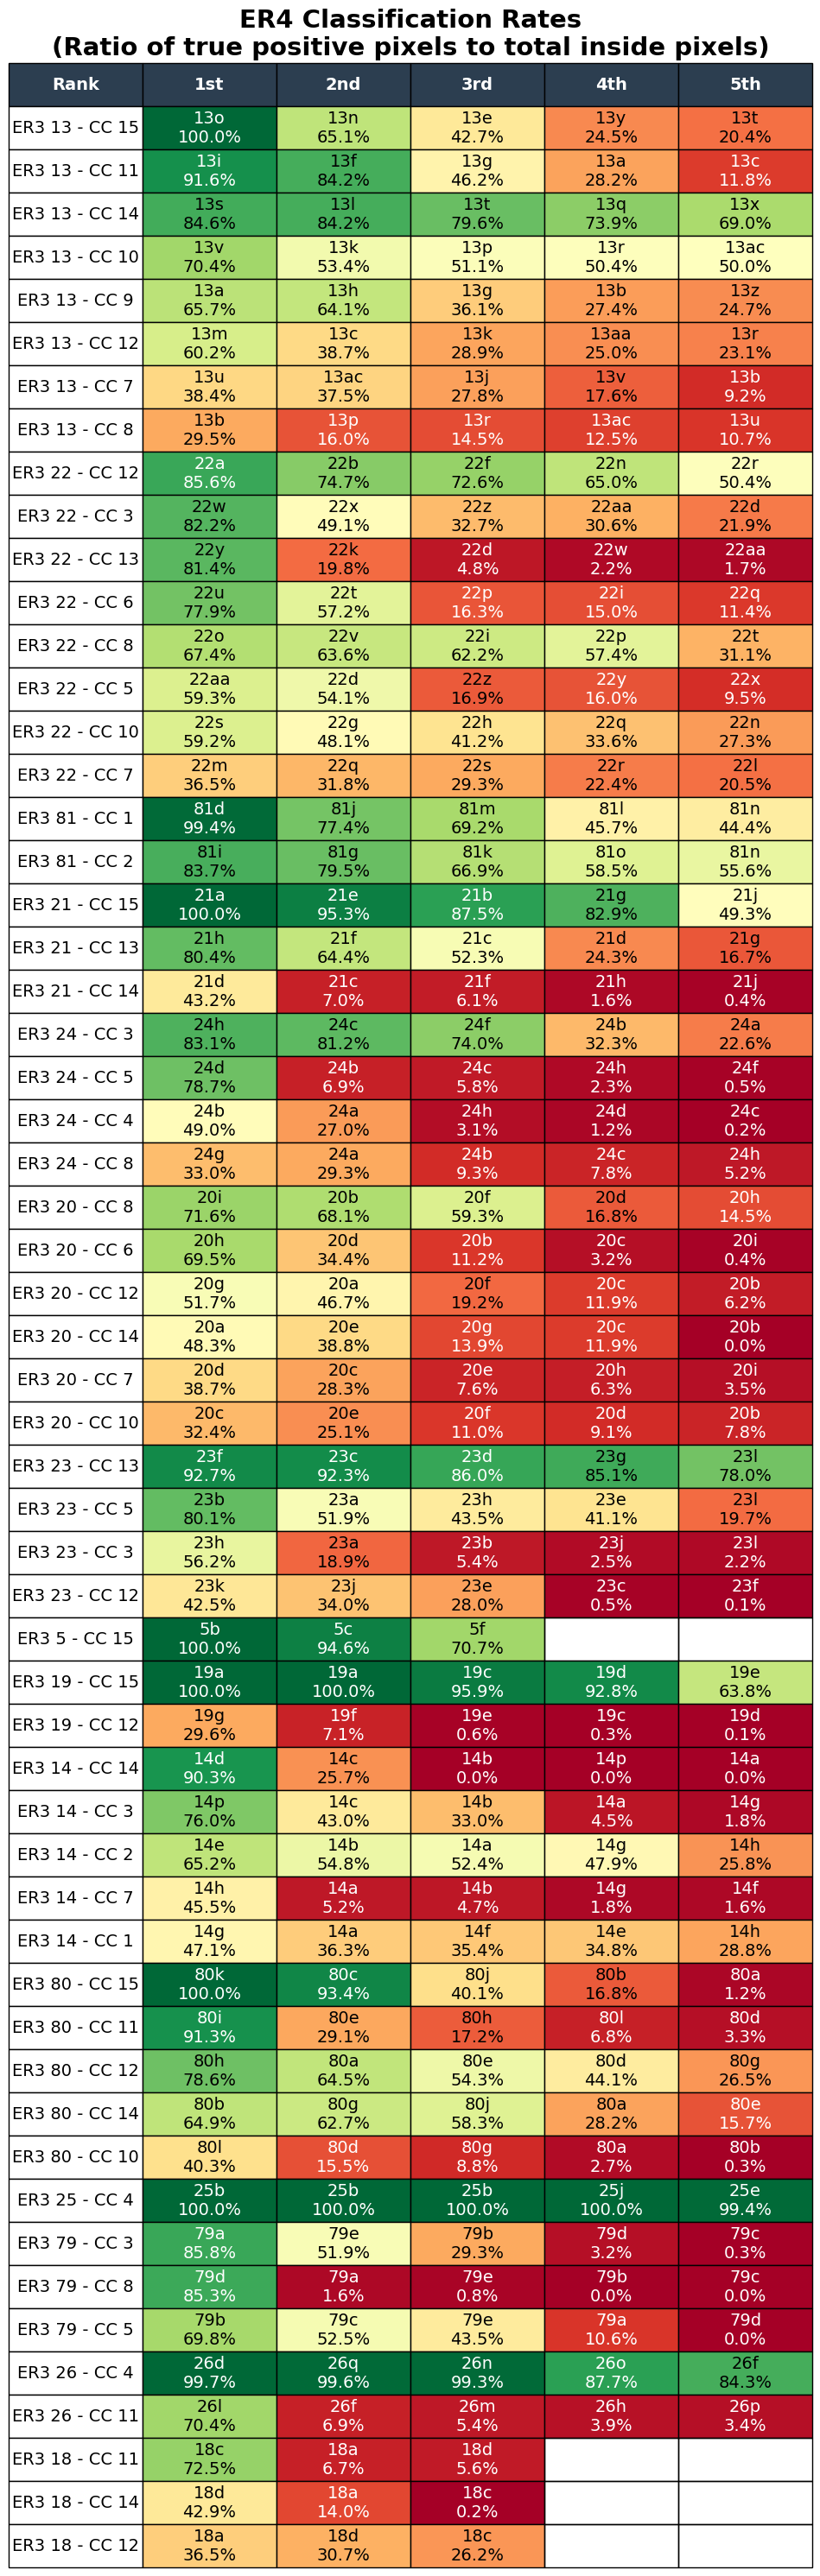

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# --- YOUR PATHS ---
tablef = '/content/drive/My Drive/Colab Notebooks/Analogs/ER4_Table.csv'
outf = '/content/drive/My Drive/Colab Notebooks/Analogs/ER4_Table.svg'


def produce_colored_table(tablef, output_filename):
    # 1. Load the data
    # We use header=0 to treat the first row (0,1,2...) as column names
    df_raw = pd.read_csv(tablef)

    data_list = []
    # 2. Iterate through pairs: Row i (Labels), Row i+1 (Values)
    for i in range(0, len(df_raw), 2):
        row_labels = df_raw.iloc[i]
        if i + 1 < len(df_raw):
            row_vals = df_raw.iloc[i+1]

            # Use .iloc[1] to get the 'ER3 13 - CC 15' style label safely
            entry = {'Label': str(row_vals.iloc[1])}

            for j in range(2, 7): # Columns 1 through 5 in your CSV structure
                item_id = str(row_labels.iloc[j])
                val_str = str(row_vals.iloc[j])

                try:
                    num_val = float(val_str.strip('%'))
                except ValueError:
                    num_val = 0.0

                entry[f'Cell_{j-1}'] = f"{item_id}\n{val_str}"
                entry[f'Val_{j-1}'] = num_val

            data_list.append(entry)

    df_clean = pd.DataFrame(data_list)

    # 3. Visualization Setup
    num_rows = len(df_clean)
    fig, ax = plt.subplots(figsize=(10, 0.5 * num_rows + 1))
    ax.axis('off')

    cmap = plt.cm.RdYlGn
    norm = mcolors.Normalize(vmin=0, vmax=100)

    display_cols = ['Label', 'Cell_1', 'Cell_2', 'Cell_3', 'Cell_4', 'Cell_5']
    table_data = df_clean[display_cols].values
    headers = ['Rank', '1st', '2nd', '3rd', '4th', '5th']

    table = ax.table(cellText=table_data, colLabels=headers, loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(14)
    table.scale(1.2, 3.0)

    # 4. Coloring and Contrast Logic
    for i in range(num_rows):
        for j in range(1, 6):
            val = df_clean.iloc[i][f'Val_{j}']
            rgba_color = cmap(norm(val))
            table[(i+1, j)].set_facecolor(rgba_color)

            # Accessibility: If color is dark, make text white
            # (Simple luminance check: r*0.299 + g*0.587 + b*0.114)
            if (rgba_color[0]*0.299 + rgba_color[1]*0.587 + rgba_color[2]*0.114) < 0.5:
                table[(i+1, j)].get_text().set_color('white')

    # Header Styling
    for j in range(6):
        table[(0, j)].set_facecolor('#2c3e50')
        table[(0, j)].get_text().set_color('white')
        table[(0, j)].get_text().set_weight('bold')

    plt.title('ER4 Classification Rates\n(Ratio of true positive pixels to total inside pixels)',
              fontsize=21, fontweight='bold', pad=20, y=1.13)

    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    plt.show()

if __name__ == "__main__":
    produce_colored_table(tablef, outf)